# K-Means Clustering: A Comprehensive Guide

K-Means is one of the most popular unsupervised learning algorithms. It partitions data into K clusters, where each data point belongs to the cluster with the nearest centroid (cluster mean).

In this notebook, we'll cover:
1. Basic concepts of K-Means Clustering
2. Data preparation and visualization
3. Model implementation from scratch
4. Using scikit-learn for K-Means
5. Finding the optimal K and model evaluation

# Simple Explanation: What Does the Code Below Do?

Imagine you work at a post office and need to group thousands of packages by destination region. You don't know the regions in advance — you just notice that some packages go to similar locations and you group them together.

K-Means does this automatically:
1. **Initialize**: Place K random centroids (cluster centers).
2. **Assign**: Each data point joins the nearest centroid's cluster.
3. **Update**: Move each centroid to the mean position of its cluster.
4. **Repeat**: Steps 2-3 until clusters stop changing.

Here's what the code does:
1. Generates blob clusters for visualization.
2. Implements K-Means from scratch showing the centroid update process.
3. Uses scikit-learn to cluster real data.
4. Uses the Elbow Method to find the optimal number of clusters.

In short: K-Means finds natural groupings in data without any labels!

In [1]:
# Create a virtual environment and install required libraries
import os
import sys

venv_dir = 'ml_env'
if not os.path.exists(venv_dir):
    os.system(f'{sys.executable} -m venv {venv_dir}')
    print(f'Virtual environment created at {venv_dir}')
else:
    print(f'Virtual environment already exists at {venv_dir}')

pip_path = os.path.join(venv_dir, 'Scripts', 'pip')
if sys.platform == 'win32':
    pip_path += '.exe'

if os.path.exists(pip_path):
    os.system(f'"{pip_path}" install numpy pandas matplotlib seaborn scikit-learn')
    print('Required libraries installed in the virtual environment.')
else:
    print('Could not find pip in the virtual environment. Please check your Python installation.')

Virtual environment already exists at ml_env
Required libraries installed in the virtual environment.


# 1. Required Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# 2. Generating Sample Data

Dataset shape: (300, 2)
True number of clusters: 4


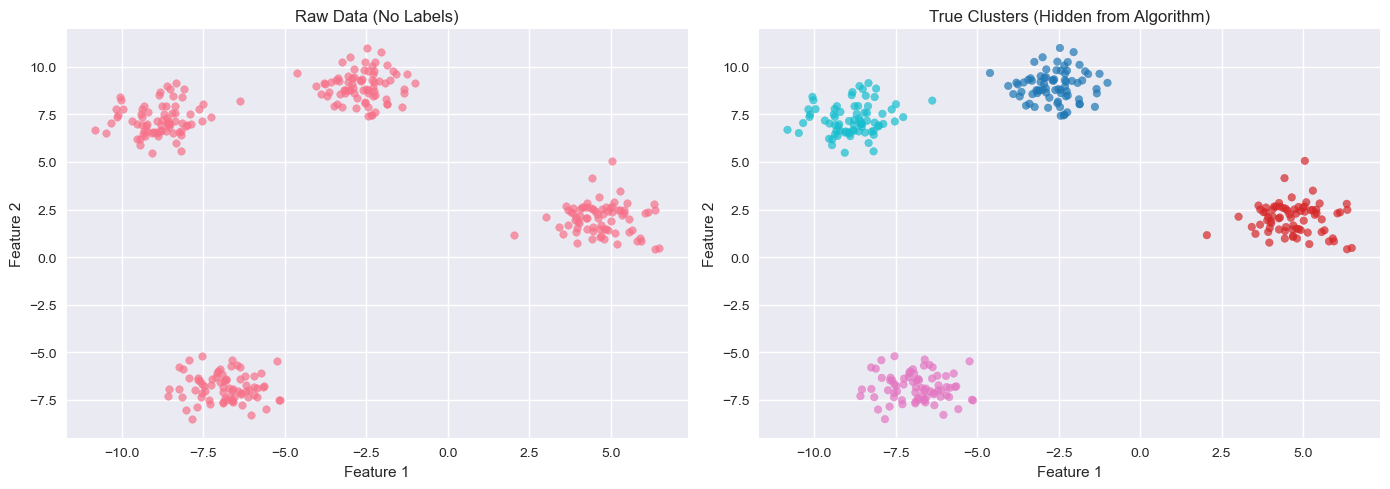

In [3]:
# Generate blob clusters
X, true_labels = make_blobs(n_samples=300, centers=4, cluster_std=0.8, random_state=42)

print('Dataset shape:', X.shape)
print('True number of clusters: 4')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Raw data (no labels - as seen by K-Means)
axes[0].scatter(X[:, 0], X[:, 1], alpha=0.7, s=30)
axes[0].set_title('Raw Data (No Labels)')
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')

# True clusters
axes[1].scatter(X[:, 0], X[:, 1], c=true_labels, cmap='tab10', alpha=0.7, s=30)
axes[1].set_title('True Clusters (Hidden from Algorithm)')
axes[1].set_xlabel('Feature 1')
axes[1].set_ylabel('Feature 2')

plt.tight_layout()
plt.show()

# 3. Implementing K-Means from Scratch

The algorithm:
1. Initialize K centroids randomly from the data.
2. Assign each point to the nearest centroid (Euclidean distance).
3. Recompute centroids as the mean of assigned points.
4. Repeat until convergence (centroids don't move significantly).

Converged at iteration 7


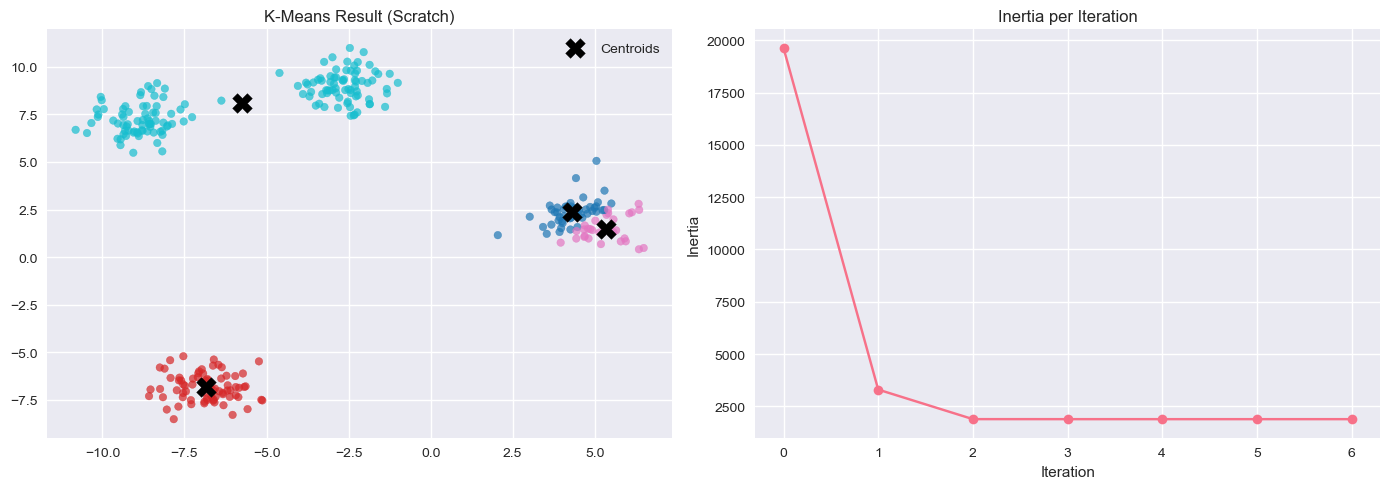

In [4]:
class KMeansScratch:
    def __init__(self, k=3, max_iters=100, tol=1e-4, random_state=42):
        self.k = k
        self.max_iters = max_iters
        self.tol = tol
        self.random_state = random_state
        self.centroids = None
        self.labels = None
        self.inertia_history = []

    def _euclidean_distance(self, a, b):
        return np.sqrt(np.sum((a - b) ** 2, axis=1))

    def fit(self, X):
        rng = np.random.RandomState(self.random_state)
        # Initialize centroids from random data points
        idx = rng.choice(len(X), size=self.k, replace=False)
        self.centroids = X[idx].copy()

        for iteration in range(self.max_iters):
            # Assign clusters
            distances = np.array([self._euclidean_distance(X, c) for c in self.centroids])
            self.labels = np.argmin(distances, axis=0)

            # Compute inertia (sum of squared distances)
            inertia = sum(np.sum((X[self.labels == k] - self.centroids[k]) ** 2) 
                          for k in range(self.k))
            self.inertia_history.append(inertia)

            # Update centroids
            new_centroids = np.array([X[self.labels == k].mean(axis=0) 
                                      if np.any(self.labels == k) else self.centroids[k]
                                      for k in range(self.k)])

            # Check convergence
            if np.max(np.linalg.norm(new_centroids - self.centroids, axis=1)) < self.tol:
                print(f'Converged at iteration {iteration + 1}')
                break
            self.centroids = new_centroids

        return self

# Run K-Means
km_scratch = KMeansScratch(k=4, random_state=42)
km_scratch.fit(X)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(X[:, 0], X[:, 1], c=km_scratch.labels, cmap='tab10', alpha=0.7, s=30)
axes[0].scatter(km_scratch.centroids[:, 0], km_scratch.centroids[:, 1], 
                c='black', marker='X', s=200, label='Centroids')
axes[0].set_title('K-Means Result (Scratch)')
axes[0].legend()

axes[1].plot(km_scratch.inertia_history, marker='o')
axes[1].set_title('Inertia per Iteration')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Inertia')
axes[1].grid(True)

plt.tight_layout()
plt.show()

# 4. Using Scikit-learn's K-Means

Scikit-learn's implementation uses K-Means++ initialization (smarter centroid initialization) and is much more optimized.

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


Inertia: 362.47
Silhouette Score: 0.8335


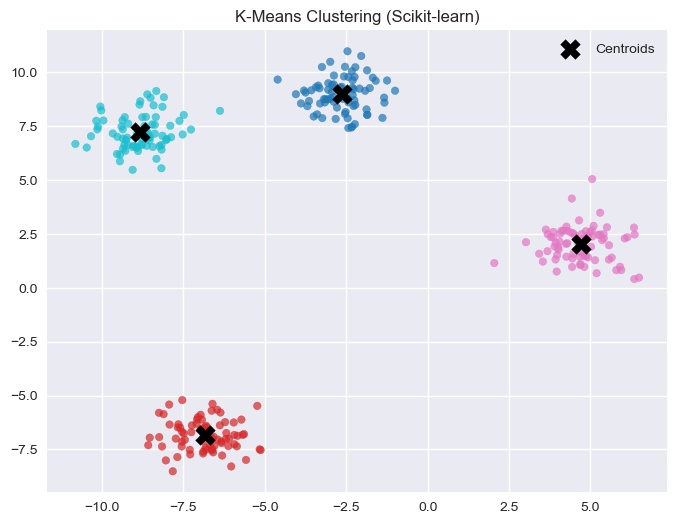

In [5]:
# Standard KMeans
kmeans = KMeans(n_clusters=4, init='k-means++', n_init=10, random_state=42)
kmeans.fit(X)

print(f'Inertia: {kmeans.inertia_:.2f}')
print(f'Silhouette Score: {silhouette_score(X, kmeans.labels_):.4f}')

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=kmeans.labels_, cmap='tab10', alpha=0.7, s=30)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
            c='black', marker='X', s=200, label='Centroids')
plt.title('K-Means Clustering (Scikit-learn)')
plt.legend()
plt.show()

# 5. Finding Optimal K — Elbow Method and Silhouette Score

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Window

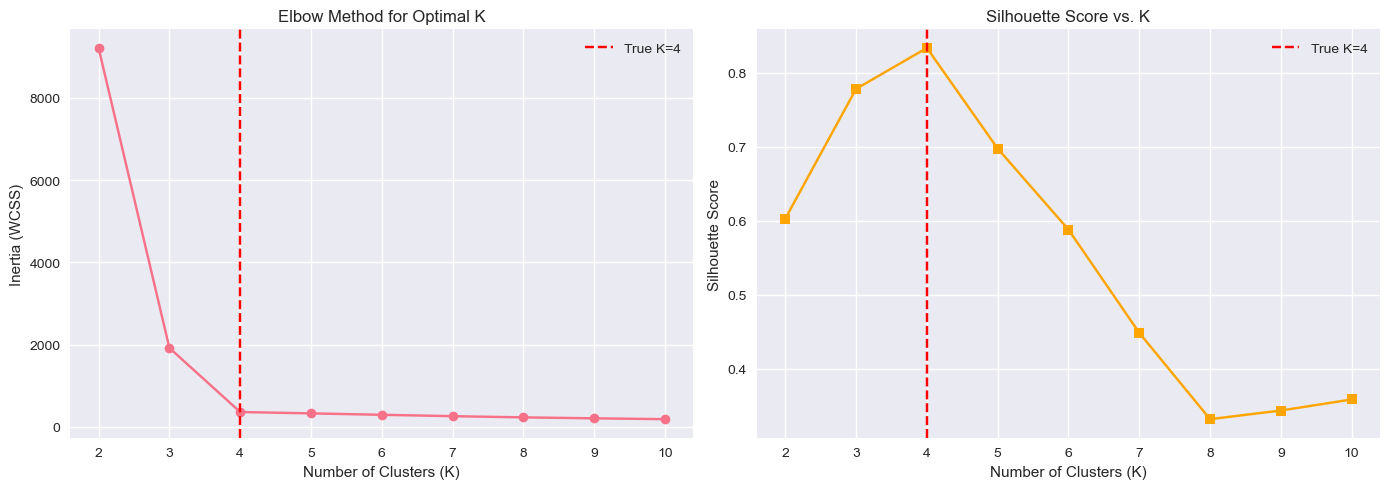


Key Insights:
- Elbow Method: Look for the "kink" (elbow) in the inertia curve.
- Silhouette Score: Closer to 1.0 is better (well-separated clusters).
- K-Means assumes spherical clusters — use DBSCAN for arbitrary shapes.
- Always scale features before clustering!


In [6]:
k_range = range(2, 11)
inertias = []
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow Method
axes[0].plot(k_range, inertias, marker='o')
axes[0].axvline(x=4, color='red', linestyle='--', label='True K=4')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_title('Elbow Method for Optimal K')
axes[0].legend()
axes[0].grid(True)

# Silhouette Scores
axes[1].plot(k_range, silhouettes, marker='s', color='orange')
axes[1].axvline(x=4, color='red', linestyle='--', label='True K=4')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score vs. K')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

print('\nKey Insights:')
print('- Elbow Method: Look for the "kink" (elbow) in the inertia curve.')
print('- Silhouette Score: Closer to 1.0 is better (well-separated clusters).')
print('- K-Means assumes spherical clusters — use DBSCAN for arbitrary shapes.')
print('- Always scale features before clustering!')

# Conclusions and Key Takeaways
K-Means is the most popular, rapidly convergent, partitional clustering algorithm. It aims to partition data into 'K' distinct, non-overlapping subsets (clusters).
- **Centroids**: Functions by iteratively placing K centroids and assigning every data point to the nearest centroid.
- **Fast and Scalable**: Exceptionally efficient with an O(N) complexity for a set number of iterations, making it viable for huge datasets.
- **Assumption Heavy**: Strongly assumes clusters are spherical, equally sized, and equally dense, severely struggling with intertwined or irregularly shaped data.

# Pros and Cons
**Pros:**
- Computationally extremely fast and easy to implement.
- Scales easily to massive datasets.
- Guarantees convergence (though usually to a local minimum, not necessarily a global optimum).

**Cons:**
- You must manually guess and specify the number of clusters 'K' beforehand.
- Highly sensitive to the initial random placement of centroids.
- Coerces all data into circular/spherical shapes, failing terribly on curved or non-linear geometrical clusters.
- Susceptible to extreme skew from outliers since it relies on continuous mean calculations.

# 15 Interview Questions and Answers

1. **How does the K-Means algorithm work?**
   *Answer*: 1) Randomly initialize K centroids. 2) Assign every point to the nearest centroid. 3) Recalculate the position of the centroid to be the mean of all points assigned to it. 4) Repeat steps 2 and 3 until the centroids stop moving (convergence).

2. **How does initialization affect the outcome?**
   *Answer*: Because the algorithm stops at local minima, a poor random starting initialization of centroids can lead to vastly incorrect final clusters. Running it multiple times and picking the best variance is standard practice.

3. **What is K-Means++?**
   *Answer*: A smart initialization technique that forces the initial K centroids to be as far apart from each other as possible. This drastically speeds up convergence and reduces the likelihood of falling into poor local minima.

4. **What is WCSS (Inertia)?**
   *Answer*: Within-Cluster Sum of Squares. It's the sum of the squared distances between each data point and its corresponding cluster centroid. The algorithm seeks to minimize this value.

5. **How do you determine the optimal number of clusters 'K'?**
   *Answer*: Using the Elbow Method or the Silhouette Score. 

6. **Explain the Elbow Method.**
   *Answer*: You plot the WCSS (Inertia) against multiple values of K. As K increases, WCSS inherently decreases. The "elbow" is the point on the curve where the rate of decrease drops sharply, indicating the optimal K before overfitting.

7. **Explain the Silhouette Score.**
   *Answer*: It measures how similar an object is to its own cluster compared to other clusters. It ranges from -1 to 1. A score near 1 means the point is far away from the neighboring clusters, implying very well-defined, robust clustering.

8. **Is scaling necessary for K-Means?**
   *Answer*: Absolutely critical. Because K-Means relies entirely on Euclidean distance to assign points to centroids, unscaled features with large ranges will completely dominate the clustering outcome.

9. **Can K-Means handle categorical data?**
   *Answer*: Not natively, because computing the "mean" of highly sparse, one-hot encoded categorical data produces meaningless, non-interpretable cluster centers in Euclidean space. An variant called K-Modes must be used instead.

10. **How does K-means handle outliers?**
    *Answer*: Poorly. Because it uses the *mean* to update centroid locations, a single extreme outlier will drag the centroid drastically away from the true center of the cluster mass.

11. **What geometric shape does K-Means assume for clusters?**
    *Answer*: Spherical (or convex isotropic). It assumes clusters are uniformly dense and circular. It fails spectacularly on half-moons or concentric circle datasets.

12. **Why does K-Means sometimes produce empty clusters?**
    *Answer*: If an initial centroid is placed extremely far away from the main data mass, no points might be assigned to it during the first step, leaving it empty.

13. **Is K-Means deterministic?**
    *Answer*: No. If you use random initialization, different runs will produce different results. Only if you use a fixed random seed or a strict deterministic initial selection will it yield the exact same result.

14. **What is Mini-Batch K-Means?**
    *Answer*: A variant used for massive datasets. Instead of using the entire dataset to update the centroids at each step, it uses random mini-batches of data, vastly speeding up the process with only a tiny negligible loss in cluster quality.

15. **Compared to DBSCAN, when would you use K-Means?**
    *Answer*: When your dataset is incredibly massive, when you are confident the clusters are somewhat spherical and equally sized, when you absolutely need to partition *every* point (no "noise" labels allowed), and when you already securely know the business value of 'K'.
